**Students:** Eilon Udi, Barak Ozmo

**Institution:** Reichman University, Computer Science

**Class:** NLP Seminar



# 1. Introduction: Improving Large Language Models
Over the past few years, LLMs have revolutionized the field of natural language processing.  
Through massive scaling of model size, training data, and compute power, current large language models have achieved remarkable capabilities in text generation, translation, coding, and even basic reasoning.

Yet despite this progress, LLMs still face fundamental challenges when it comes to complex, multi-step reasoning tasks — such as solving math word problems, commonsense reasoning, or writing formal code proofs.  

**Two complementary techniques** have recently emerged to address these challenges:

## Chain-of-Thought Prompting Elicits Reasoning in Large Language Models (2023)

The first technique is called **Chain-of-Thought prompting**.  
Introduced by researchers at Google, CoT is based on a simple but powerful idea:  
Instead of asking the model to directly output the final answer, we encourage it to **think step-by-step** — just like a human would.

By inserting a *chain* of intermediate reasoning steps into the prompt examples, we guide the model to *decompose* complex problems, *reason sequentially*, and often arrive at better answers.  
For example, instead of answering "Roger has 5 tennis balls and buys 2 cans of 3 balls each — how many does he have?", in one step, the model breaks it down:  
- "Roger started with 5 balls."  
- "Each can has 3 balls, so 2 cans have 6 balls."  
- "Adding them together gives 11 balls."

Empirical results show that Chain-of-Thought prompting dramatically improves performance on tasks like arithmetic reasoning, symbolic manipulation, and commonsense questions — especially when used with very large models, above 100 billion parameters.

## Large Language Monkeys: Scaling Inference Compute with Repeated Sampling (2024)

The second technique is **Repeated Sampling at Inference**, proposed in more recent work from Stanford and DeepMind.  
Here, the motivation is different:  
While training-scale has been well-explored, **inference-time scaling** — what happens after training — is still an underused lever.

Normally, when we ask a model a question, we only sample **one** answer.  
But what if, instead, we sample **hundreds or thousands of answers**, and then **choose the best** among them?

By generating many candidate solutions — each slightly different — we can dramatically increase the chances that *at least one* sample is correct.  
This technique is especially powerful when paired with **automatic verifiers**, such as unit tests for code, or proof checkers for math.

Across multiple tasks like programming, formal theorem proving, and complex math problems, repeated sampling has been shown to **boost success rates by hundreds of percent**.  
It even allows weaker, cheaper models to outperform the single-shot performance of stronger frontier models like GPT-4o.





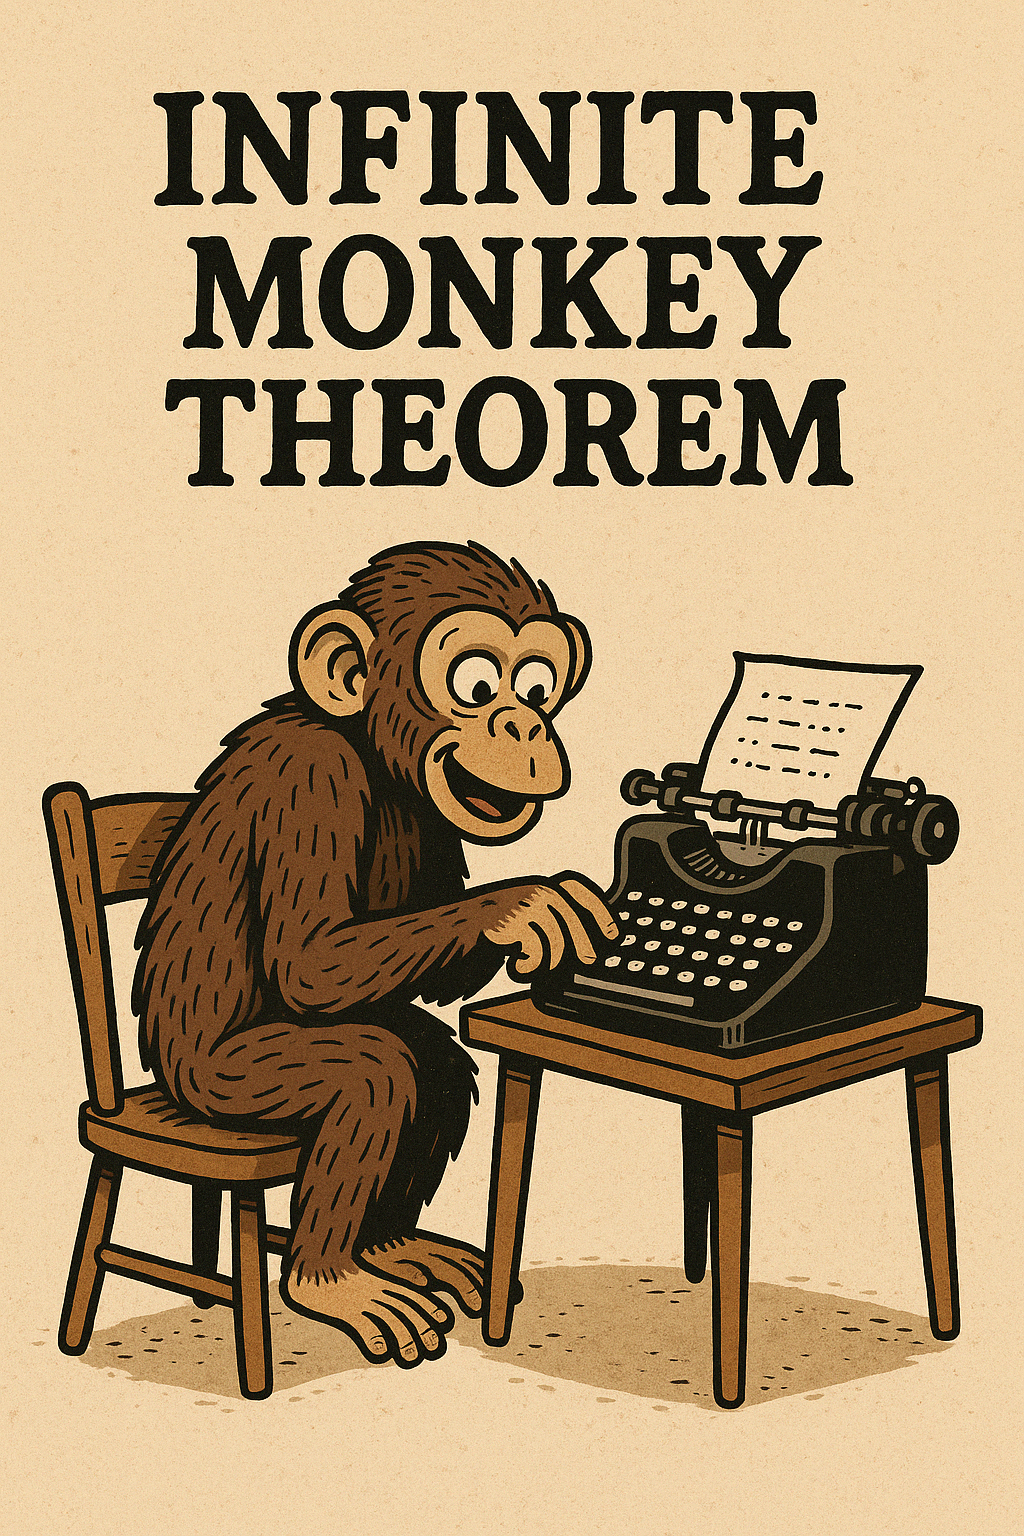

# 🐒 Infinite Monkey Theorem Explained

The **Infinite Monkey Theorem** is a classic thought experiment in probability theory. It goes something like this:

> **"If you had a monkey randomly pressing keys on a typewriter for an infinite amount of time, eventually it would almost surely type out the complete works of Shakespeare (or any other text you choose)."**



In other words, given infinite time and randomness, all possible finite sequences of text will eventually appear. That includes Hamlet, your favorite tweet, or even this message I'm writing right now.



## Why These Techniques Matter

Together, these two techniques reveal a crucial insight:  
- **Model scale is not everything.**  
- **Prompt design** and **inference strategies** are powerful tools.

Chain-of-Thought shows how a model’s *thinking process* can be shaped just by changing the examples we show it.  
Repeated Sampling shows how *giving the model multiple chances* — and picking the best outcome — can dramatically enhance reliability, even without retraining.

In this seminar, we'll explore **how each technique works**, **their impact on real-world tasks**, **their limitations**, and **how they complement each other** toward building more reliable, reasoning-capable AI systems.

# What is GSM8K?
The GSM8K (Grade School Math 8K) dataset is a benchmark for evaluating the mathematical reasoning abilities of language models. It consists of 8,500 high-quality, crowd-sourced grade school-level math word problems, designed to test multi-step reasoning and problem-solving skills. Each problem typically requires understanding the question, performing multiple arithmetic steps, and arriving at the correct solution. For example:

**Problem:**  
Tom has 3 packs of pencils. Each pack contains 12 pencils. He gives 10 pencils to his friend. How many pencils does Tom have left?

**Solution:**  
First, calculate the total number of pencils: 3 packs × 12 pencils = 36 pencils.  
Then subtract the pencils given away: 36 - 10 = 26 pencils.  
**Answer:** 26

This type of problem demonstrates the step-by-step reasoning required in GSM8K, making it a valuable resource for training and evaluating models on math reasoning tasks.


# 2.      Chain-of-Thought: idea, impact, limitations

Source: Chain-of-Thought Prompting Elicits Reasoning in Large Language Models https://arxiv.org/abs/2201.11903 (Jason Wei, Xuezhi Wang, Dale Schuurmans, Maarten Bosma, Brian Ichter, Fei Xia, Ed Chi, Quoc Le, Denny Zhou)

Based on the paper: "Chain-of-Thought Prompting Elicits Reasoning in Large Language Models" by Wei et al. (2022-2023).

## The Problem
LLMs have shown incredible capabilities, but they often struggle with tasks requiring multi-step reasoning, like arithmetic word problems, commonsense reasoning, and symbolic manipulation.

## Idea

**Chain-of-Thought prompting** is a method where the model is guided to produce intermediate reasoning steps before reaching a final answer.

Instead of jumping straight to the output, the model is asked to **"think step-by-step"**, mirroring how humans solve complex tasks.

For example, solving a math word problem can be decomposed into smaller logical steps, and by showing these in the prompt, the model learns to imitate this reasoning pattern.

## Example 1 - Math Questions

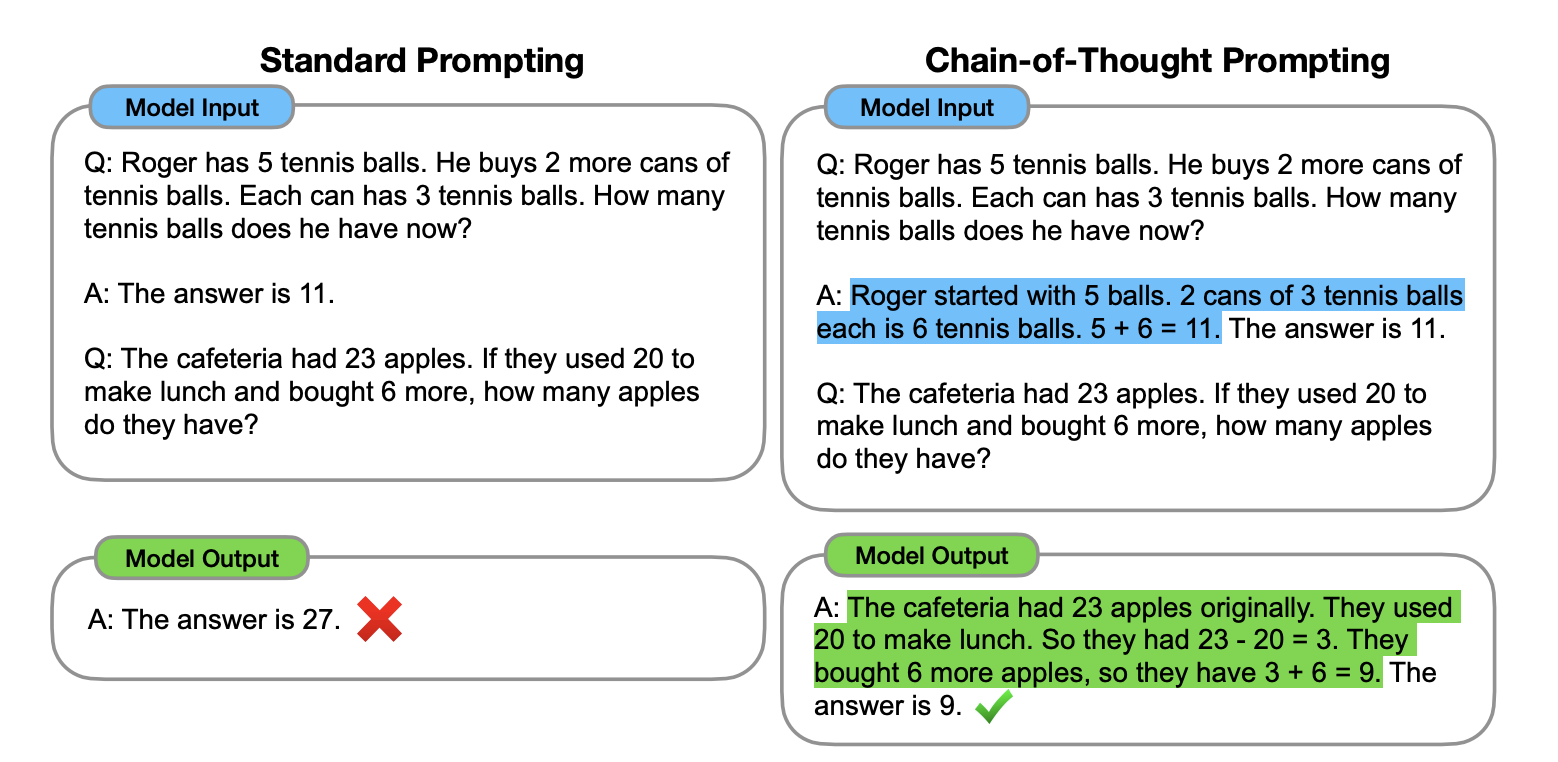


# What did the writers do?

for most benchmarks (GSM8K, SVAMP, MAWPS, etc.), the models were prompted with 8 CoT examples.

for AQuA (since it's multiple choice), they used 4 exemplars instead.

# Results -

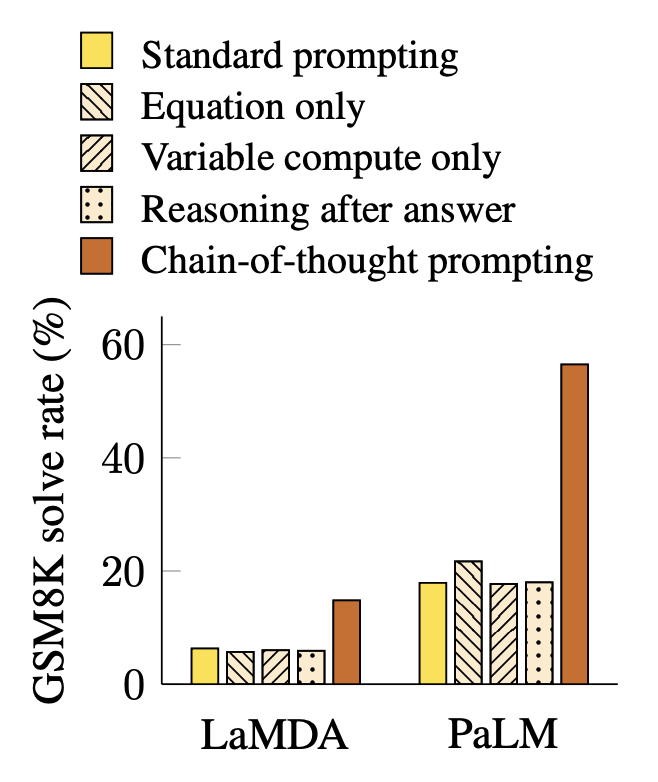

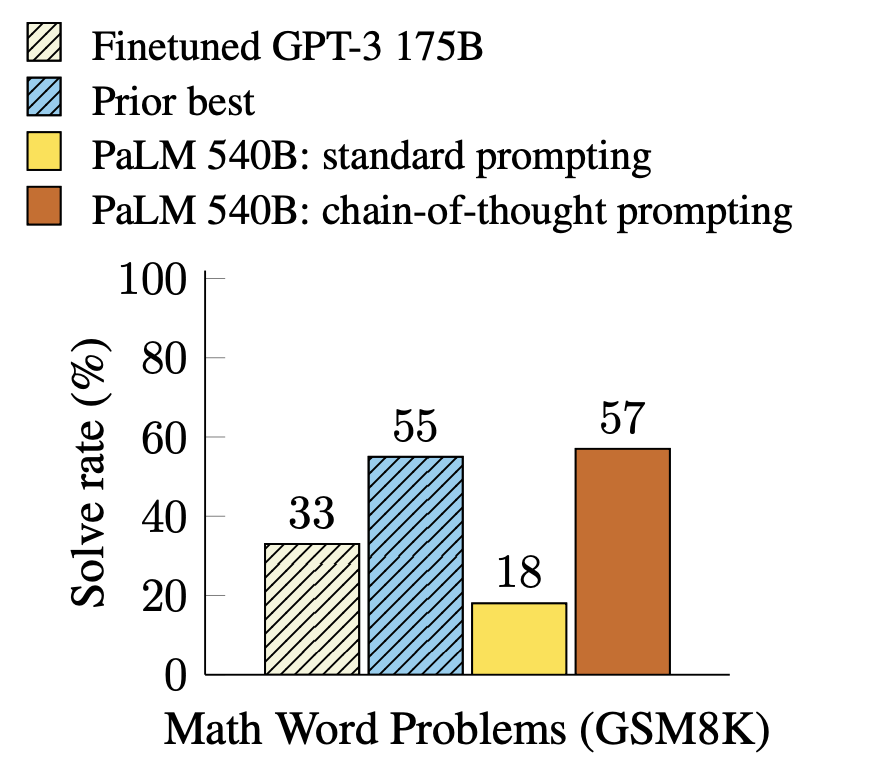

#  Results: Chain-of-Thought Prompting in Practice

The strongest results of Chain-of-Thought (CoT) prompting are summarized in the study's Figure 4, with full outputs across model families, sizes, and benchmarks detailed in the Appendix.

We highlight **four major takeaways** from these experiments:

## Chain-of-Thought as an Emergent Ability

CoT prompting shows **no significant benefit** for small language models.  
Performance improvements only emerge when using **very large models** — typically above **100B parameters**.

- Small models generate fluent but **illogical** chains of thought.
- Large models like **GPT-3 (175B)** and **PaLM (540B)** demonstrate substantial reasoning improvements once prompted step-by-step.

This shows CoT is an **emergent behavior** that depends on **scaling**.

## Bigger Gains on More Complex Tasks

The benefits of CoT prompting are **greater for more difficult problems**.

- On **GSM8K** (a challenging math word problem dataset), CoT more than **doubles** solve rates in large models.
- On **MAWPS**, specifically the **SingleOp** subset (which only requires one reasoning step), performance gains are minimal or even negative.

This suggests CoT is most effective when **multi-step reasoning** is essential.

## State-of-the-Art Performance Without Finetuning

CoT prompting using **off-the-shelf large models** (e.g. GPT-3 175B, PaLM 540B) **matches or beats** prior **finetuned supervised models** on several benchmarks:

- **GSM8K**: New state-of-the-art solve rate
- **SVAMP**: CoT prompting **outperforms standard prompting** and nears prior SOTA
- **MAWPS**: Significant improvements with PaLM 540B

Notably, CoT prompting **does not require finetuning** or labeled training data — just carefully crafted exemplars in the prompt.

## Qualitative Analysis of Model Behavior

A closer look at model outputs reveals the quality of CoT reasoning:

- Among 50 **correct answers** by LaMDA 137B on GSM8K:
  - All but 2 chains of thought were **logically valid and mathematically accurate**
- Among 50 **incorrect answers**:
  - ~46% had *minor* reasoning mistakes (e.g. calculation errors)
  - ~54% had *major* issues in semantic understanding or coherence

Further analysis showed that **scaling up** from **PaLM 62B → PaLM 540B** fixed a large portion of semantic and step-skipping errors, reinforcing that **scale boosts reasoning reliability**.


## Visual Summary

*Figure 4 (from the paper)* illustrates how CoT prompting performance increases with **model size** across three datasets:

| Model Scale (B) | GSM8K | SVAMP | MAWPS |
|------------------|--------|--------|--------|
| Small (≤8B)      |  No gain |  No gain |  No gain |
| Medium (62B)     |  Some gain |  Small gain |  Variable |
| Large (540B)     |  Doubles solve rate |  Matches SOTA |  New SOTA |

> Prior best scores come from:
> - GSM8K: Cobbe et al. (2021)  
> - SVAMP: Jie et al. (2022)  
> - MAWPS: Lan et al. (2021)



## Impact

- **Improves Reasoning**:  
  Models perform significantly better on math, commonsense, and symbolic reasoning tasks.

- **Interpretability**:  
  By generating intermediate steps, we gain insights into **how** the model reaches its answers.

## Limitations

- **Model Size Dependency**:  
  Smaller models often generate plausible-looking but incorrect chains of thought.

- **Prompt Sensitivity**:  
  The quality and structure of the few-shot examples in the prompt greatly affect performance.

- **Cost**:  
  Generating longer outputs with reasoning steps increases **inference cost**.

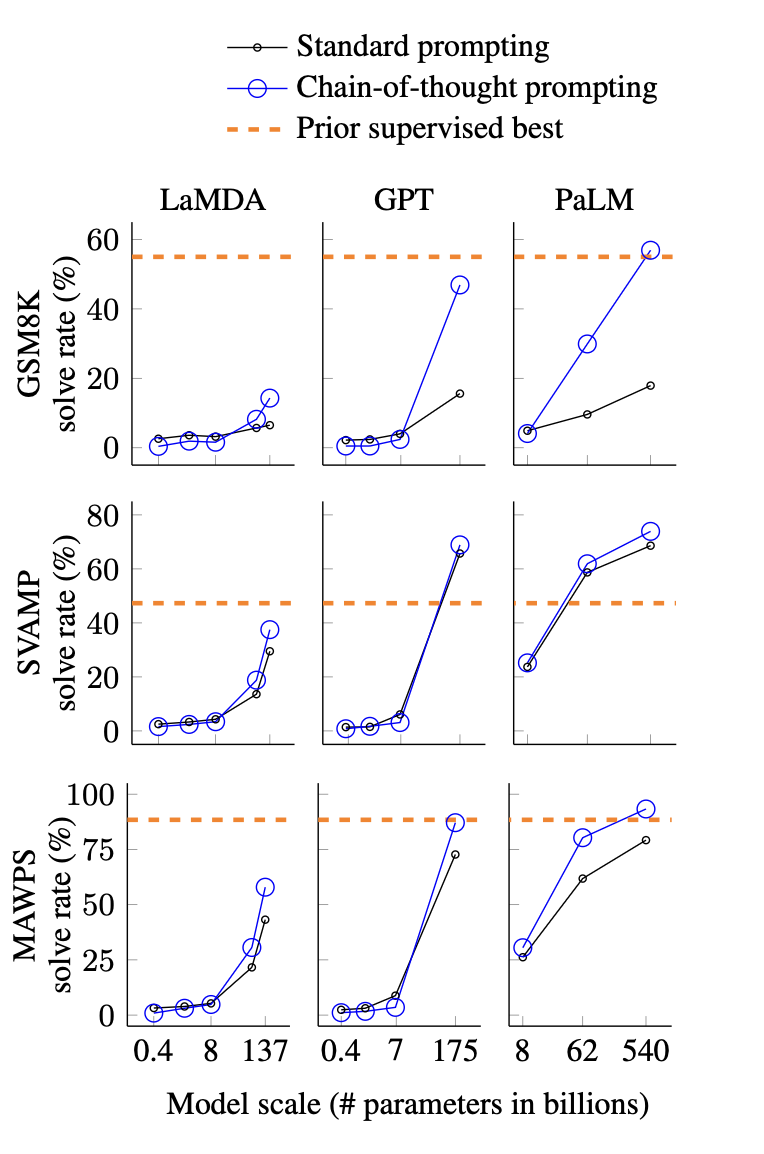


# More Examples

# Symbolic Reasoning

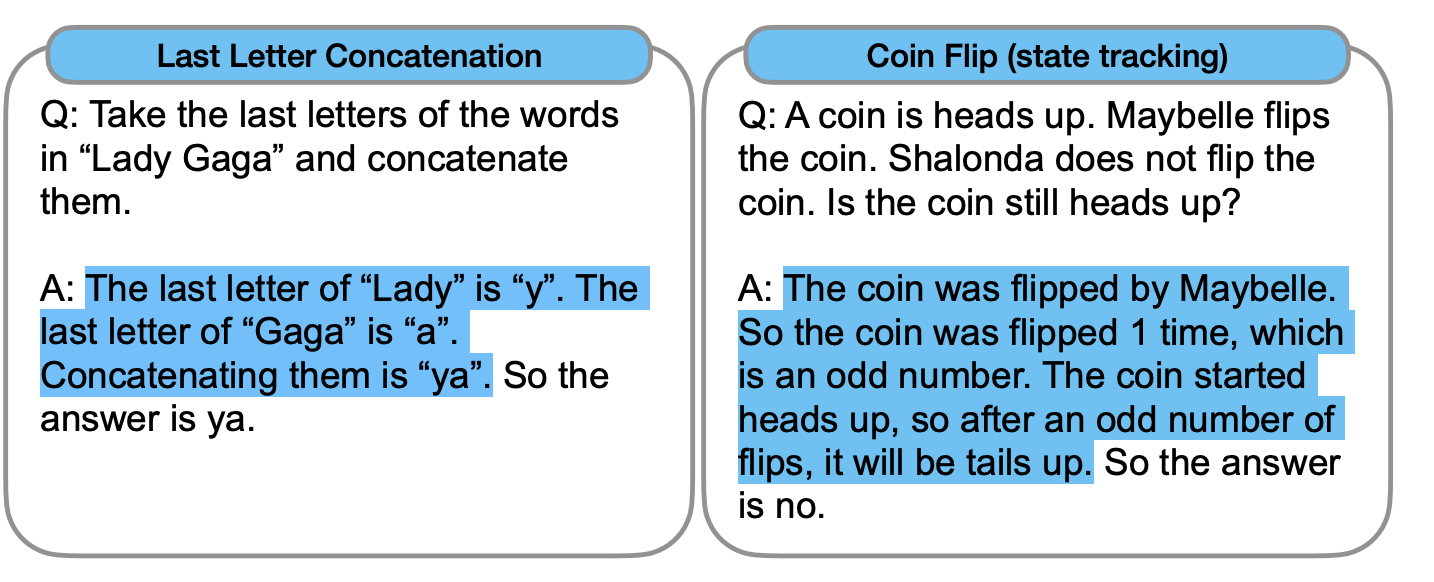

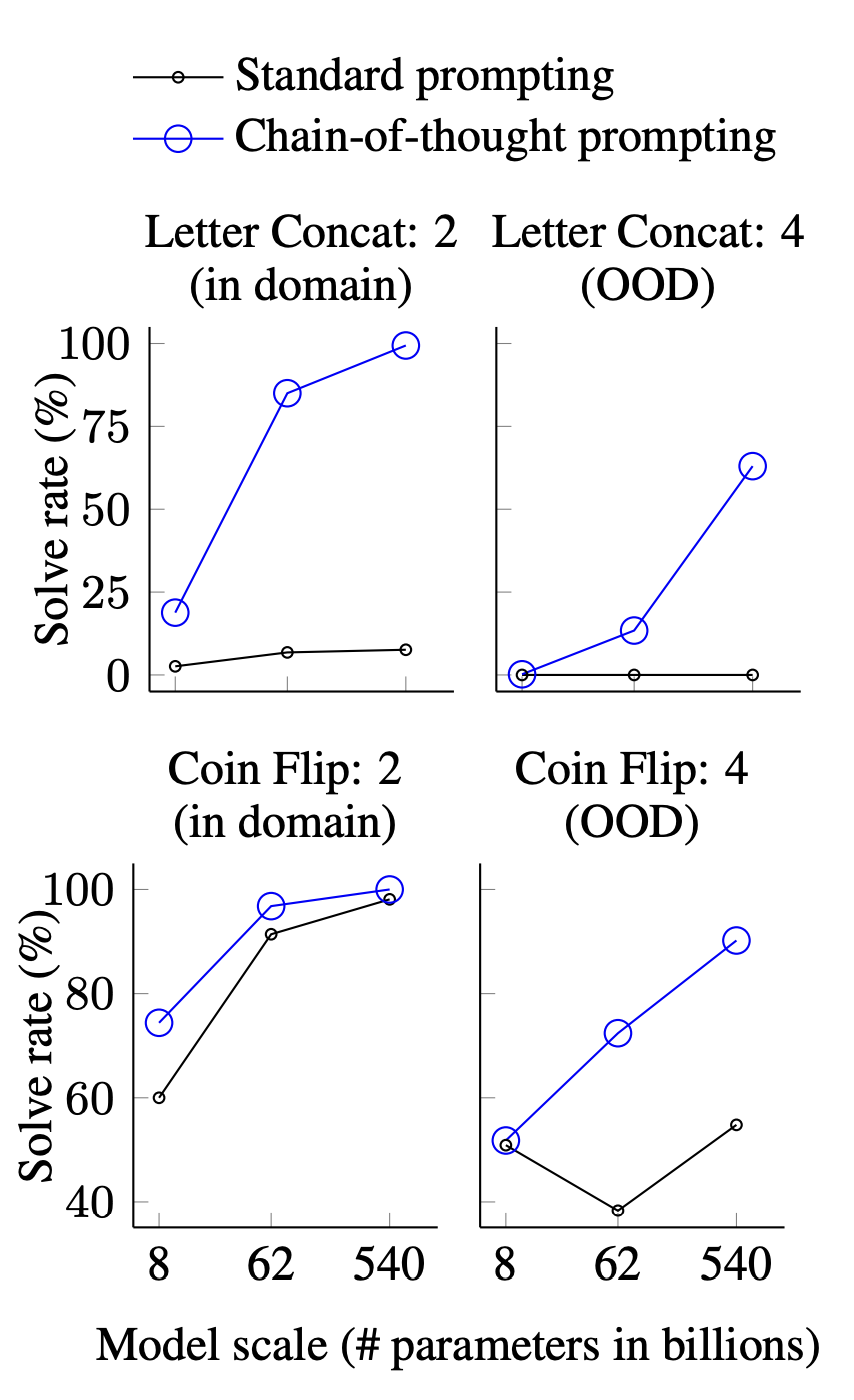

# StrategyQA, Date Understanding, Sports Understanding

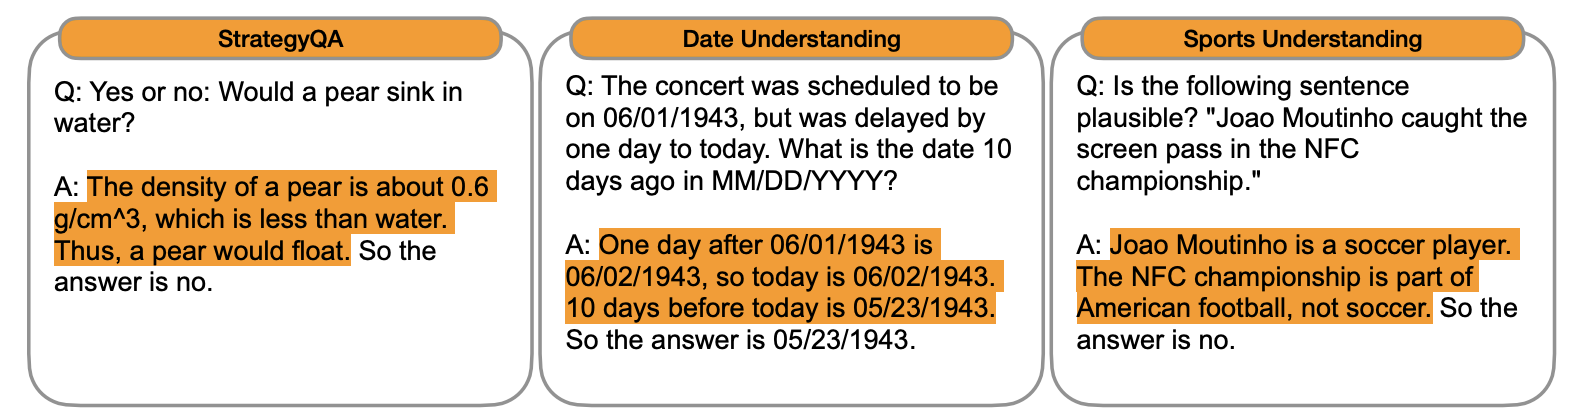

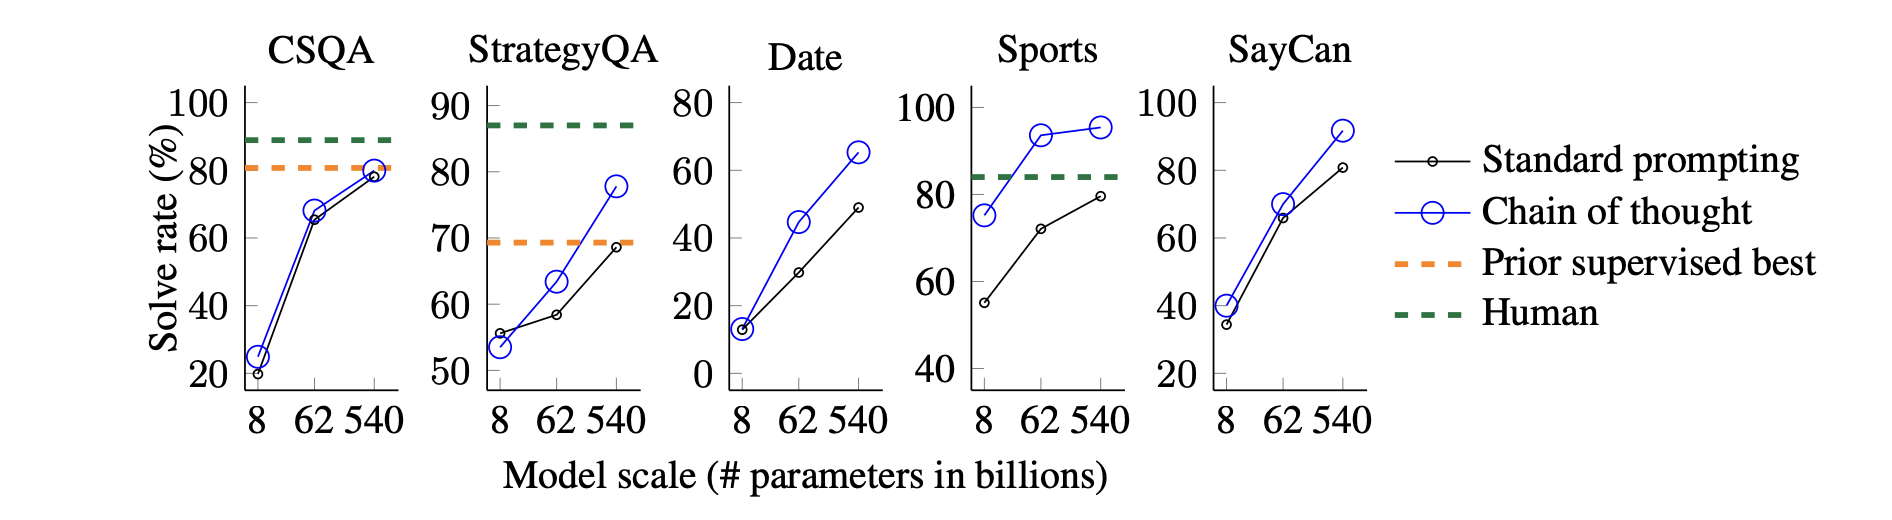

# Today - Practical Code Example: Chain-of-Thought Prompting

Let's see the difference with a real LLM using Gemini 1.5 Flash (~8B parameters)

In [ ]:
!pip install -q -U google-genai

from google import genai

client = genai.Client(api_key="")

def ask_standard_prompt(question):
    prompt = f"Q: {question}\nA:"
    response = client.models.generate_content(
        model="gemini-1.5-flash",
        contents=prompt
    )
    return response.text

def ask_chain_of_thought_prompt(question):
    cot_prompt = f"""Let's solve the following problem step-by-step:

Q: {question}
A:"""
    response = client.models.generate_content(
        model="gemini-1.5-flash",
        contents=cot_prompt
    )
    return response.text


# Example question -- standard prompting
question = "The cafeteria had 23 apples and oranges.If  they used 20 fruits to make lunch and bought 3 more apples, how many apples and oranges do they have?, give me the final answer only"
# Standard Prompt
print("Standard Prompt Answer:")
print(ask_standard_prompt(question))

print("\n---\n")

# Chain-of-Thought Prompt
print("Chain-of-Thought Prompt Answer:")
question = "The cafeteria had 23 apples and oranges. If they used 20 fruits to make lunch and bought 3 more apples, how many apples and oranges do they have?"
print(ask_chain_of_thought_prompt(question))

Standard Prompt Answer:
26


---

Chain-of-Thought Prompt Answer:
Here's how to solve this step-by-step:

1. **Start with the initial amount:** The cafeteria began with 23 apples and oranges.

2. **Subtract the used fruits:** They used 20 fruits, so 23 - 20 = 3 fruits remain.

3. **Add the new apples:** They bought 3 more apples, so 3 + 3 = 6 fruits.

**Answer:** The cafeteria now has 6 apples and oranges.  Note that we don't know the exact number of apples versus oranges.



## Why does this work?

- Allows models to break down multi-step problems into manageable intermediate steps, allocating more computation to problems needing more reasoning.
- Provides a window into the model's "thought process," offering insights into how it arrived at an answer and allowing for debugging if the reasoning is flawed.
- Useful for various tasks like math word problems, commonsense reasoning, and symbolic manipulation.


- **Final Answer Only = Minimal Reasoning**
If we ask a language model to output just the final answer, the model often bypasses the internal multi-step reasoning process, especially in complex tasks like arithmetic or symbolic reasoning. This was observed in the experiments with standard prompting, where models often failed on tasks like GSM8K when only the final answer was expected without intermediate steps

- **Asking for Step-by-Step = Elicits Reasoning**
When I prompted to generate step-by-step reasoning—i.e., a chain of thought—large models were able to decompose the problem and solve it more effectively

- **Modern Models and Internal CoT**
Many recent models (like GPT-4o or Gemini) often internally perform chain-of-thought reasoning, even when not explicitly prompted. But if we don’t ask for intermediate steps, the model may: Compress or skip steps, Hallucinate shortcuts or rely on heuristics learned during training.

# 3. Large Language Monkeys Repeated Sampling: motivation, method, results

Source: Large Language Monkeys: Scaling Inference Compute with Repeated Sampling
(Bradley Brown, Jordan Juravsky, Ryan Ehrlich, Ronald Clark, Quoc V. Le, Christopher Ré, Azalia Mirhoseini) https://arxiv.org/abs/2407.21787

So far, we've talked about Chain-of-Thought, which focuses on improving the quality of a single reasoning path. Now, let's shift gears and discuss a different approach, which is scaling the amount of compute used during inference, rather than just during training.

Think about how we typically use LLMs - we often give them a problem and expect an answer in one shot. But is that always the best approach? Scaling training compute (bigger models, more data) has yielded massive improvements, but relying on a single inference attempt might be leaving performance on the table, especially for complex tasks.

Why? Because complex problems often have multiple ways to arrive at the correct solution. A model might stumble on one path but could succeed if it tried a different route.

This leads to the core motivation for Repeated Sampling: Can we boost performance simply by letting the model try the same problem multiple times and picking the best result?. It treats inference compute as a new scaling dimension.



## Generating and Verifying
The method itself is quite straightforward. It involves two key steps:

1. **Generate Candidate Solutions**: For a single problem, we ask the LLM to generate *k* independent potential solutions. The key here is using a positive sampling temperature (temp > 0) to introduce randomness and diversity in the outputs, encouraging different reasoning paths or solutions.

2. **Verify and Select**: Once we have our *k* samples, we need a way to choose the best one, or determine if any are correct. This is done using a verifier specific to the task domain.


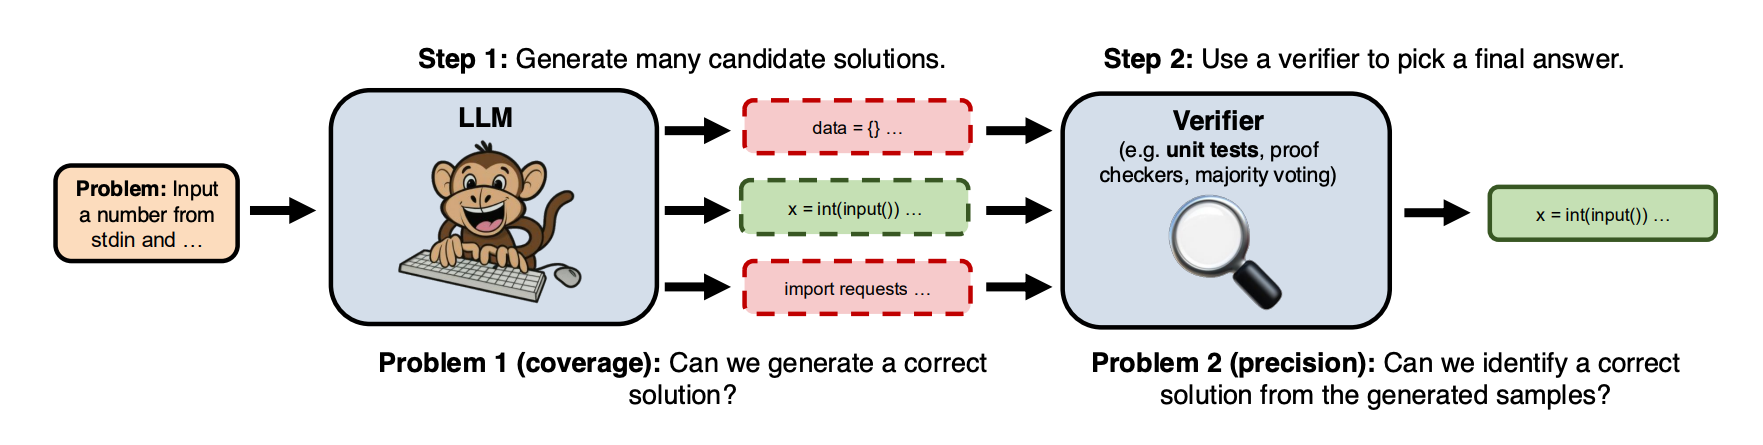


### Verifiers, Coverage & Precision

The effectiveness of the whole process really depends on that verification step and two key properties:

* **Coverage (measured in pass@k)**: What percentage of problems can the model solve with at least one correct answer within those k samples?. This tells us the model's potential performance given k tries.

* **Precision**: How good is our verifier at actually finding a correct solution if one exists in the sample set?

Both are crucial. High coverage means nothing if you can't find the correct answer (low precision). Perfect precision doesn't help if the model never generates the right answer (low coverage).


The authors needed a metric coverage that:

1. By adding more samples should never hurt the score.
2. If unit tests or a proof checker can mark a sample correct/incorrect, the metric should work automatically.
3. measures coverage only

and tha should answer the qustion - If you keep the best-case result among k independent model samples for each problem, how many problems would you solve?



The **pass@k** metric is computed using the following formula:

$$
\text{pass@k} = \frac{1}{n} \sum_{i=1}^{n} \left[ 1 - \frac{\binom{N - C_i}{k}}{\binom{N}{k}} \right]
$$

      Where:
        - ( n ) = total number of problems  
        - ( N ) = number of generated samples per problem  
        - ( C_i ) = number of correct samples (passing all unit tests) for problem ( i )  
        - ( k ) = number of samples evaluated in the metric  


### 🔢 Example 1: pass@1

Suppose you generate **N = 5** samples for a problem, and **C = 2** of them pass all unit tests.  
You want to estimate the probability that **at least one correct solution** is found in just **k = 1** sample.

Using the formula:

$$
\text{pass@1} = 1 - \frac{\binom{N - C}{1}}{\binom{N}{1}} = 1 - \frac{\binom{3}{1}}{\binom{5}{1}} = 1 - \frac{3}{5} = 0.4
$$

So, **pass@1 = 0.4** → 40% chance that a single sample would be correct.

---

### 🔢 Example 2: pass@2

Same setup: **N = 5**, **C = 2** correct samples, now evaluate **pass@2**:

$$
\text{pass@2} = 1 - \frac{\binom{3}{2}}{\binom{5}{2}} = 1 - \frac{3}{10} = 0.7
$$

So, **pass@2 = 0.7** → 70% chance that at least one of two samples would be correct.

<ins>The verifier type varies by task:</ins>

* Automatic verifiers - For coding, we can use unit tests. For formal math like Lean proofs, we have proof checkers. These are ideal because verification is reliable and automated.

* Heuristic/Model-Based verifiers: For things like math word problems (like GSM8K, MATH), where automatic checking isn't easy, common methods include:

  * Majority Voting: Picking the most frequent final answer.
  * Reward Models: Using a separate model to score solution quality, then picking the highest-scoring one (Best-of-N) or using scores to weight votes.


## Results

So, does generating more samples actually help? The striking anwer is **Yes!**

1. **Coverage Scales Impressively with growing K**

    Across coding, math, and formal proof tasks, and using models like Llama-3 and DeepSeek Coder, coverage consistently increases with the number of samples *k*, often scaling smoothly over **4x** times - from 1 sample up to 10,000.

2. **Performance Gains & State of the art (with Verifiers)**

    Crucially, where automatic verifiers exist, this increased coverage directly boosts performance.

  * Highlight Result (SWE-bench Lite): Using DeepSeek-Coder-V2-Instruct with the Moatless Tools framework, performance jumped from 15.9% solved issues (pass@1) to 56% (pass@250), significantly outperforming the prior single-attempt State of the art of 43%.


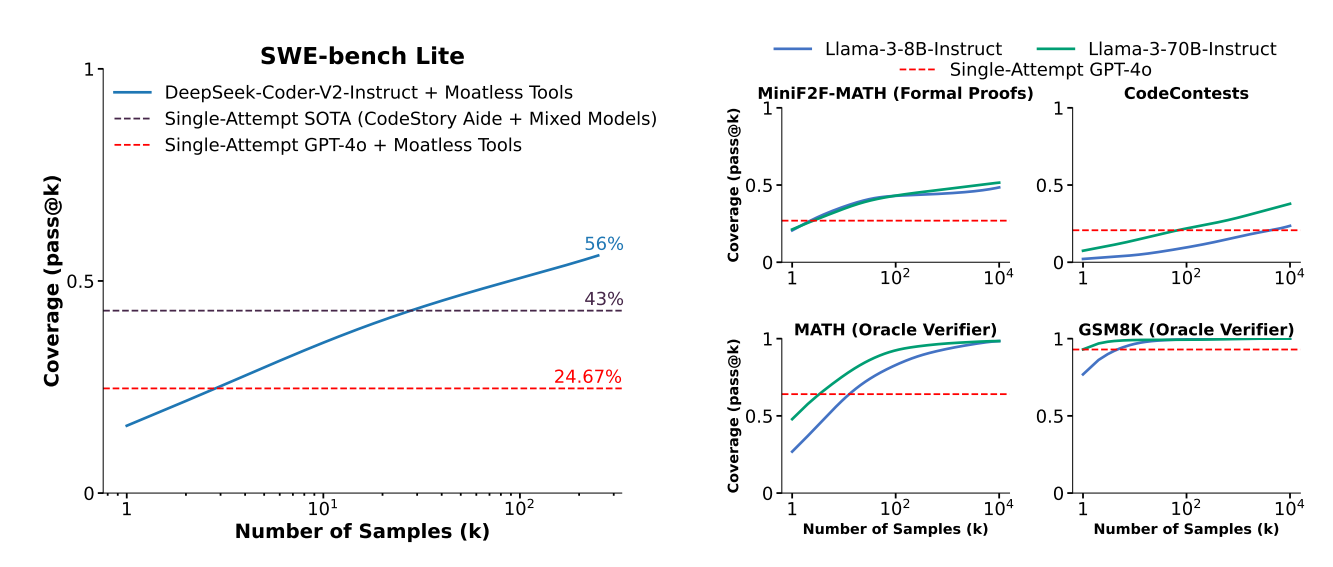

3. **Model Amplification & Cost-Effectiveness**

    Repeated sampling allows weaker/smaller models, given enough samples, to match or even exceed the single-sample performance of much stronger models.

    This gives us a new cost-performance lever.

    * Sometimes, sampling more from a smaller/cheaper model is more cost-effective (in terms of FLOPs or API pricing) than sampling less from a larger/more expensive one.

    * Example: On SWE-bench Lite, 5 samples from DeepSeek-Coder-V2-Instruct solved more issues than 1 sample from GPT-4o or Claude 3.5 Sonnet, at less than a third of the API cost.
  

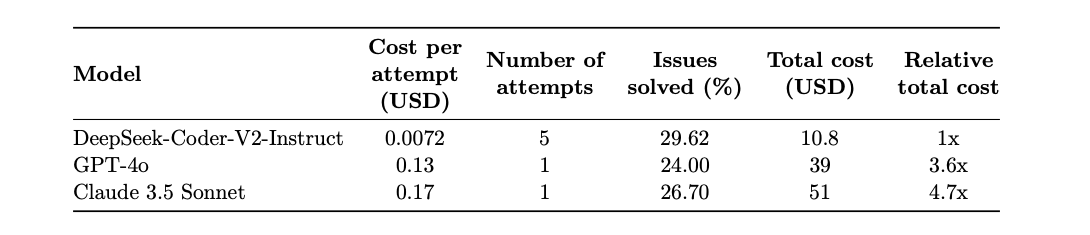


4. **The Verification Bottleneck**

    However, there's a major caveat, especially for tasks without automatic verifiers. While coverage might soar close to 100% with thousands of samples, common verification methods like Majority Voting and Reward Models often fail to scale.

    * Observation: These methods typically plateau around k=100 samples, failing to identify rare correct solutions generated at higher sample counts.
    * Why? They struggle to find the "needle in the haystack". If only 1% of 1000 samples are correct, majority voting won't pick it, and current reward models often aren't precise enough. This creates a gap between potential (coverage) and reality (precision-limited success rate).

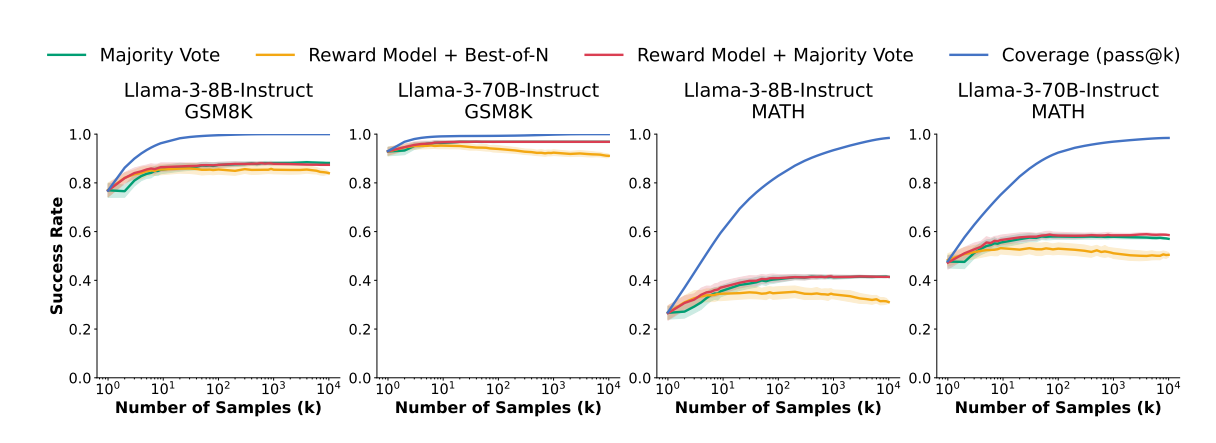

# 4.      Comparison between the two techniques (On GSM8K) // Barak + Udi

## Old comp


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

splits = {'train': 'main/train-00000-of-00001.parquet', 'test': 'main/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/openai/gsm8k/" + splits["train"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


In [ ]:
def extract_answer(answer_raw: str):
    match = re.search(r"####\s*(-?\d[\d,\.]*)", answer_raw)
    return match.group(1).replace(",", "") if match else None

In [ ]:
from openai import OpenAI

client = OpenAI(
    # This is the default and can be omitted
    api_key=OPENAI_API_KEY
)

In [ ]:
def evaluate_cot_vs_direct(model_name: str, df: pd.DataFrame, k: int = 5, test_size: int = 10):
    assert 'question' in df.columns and 'answer' in df.columns, "DataFrame must contain 'question' and 'answer' columns"

    cot_correct = 0
    direct_correct = 0

    few_shot_df = df.iloc[:k]
    test_df = df.iloc[k:k + test_size]

    # Build few-shot CoT prompt
    few_shot_prompt = "\n\n".join(
        f"Q: {row['question']}\nA: Let's think step by step.\n... Therefore, the answer is {row['answer']}."
        for _, row in few_shot_df.iterrows()
    )

    for _, row in test_df.iterrows():
        question = row['question']
        real_answer = extract_answer(str(row["answer"]).replace(",", ""))

        # --- Chain of Thought ---
        cot_prompt = f"{few_shot_prompt}\n\nQ: {question}\nA: Let's think step by step."
        try:
            cot_response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": cot_prompt}],
            )
            cot_output = cot_response.choices[0].message.content

            predicted = re.findall(r"-?\d+(?:[.,]\d+)?", cot_output)
            if predicted:
                # Take the last match and remove commas/periods unless it's a decimal point
                cot_predicted = predicted[-1].replace(",", "").strip(".")
                if cot_predicted == real_answer:
                    cot_correct += 1

        except Exception as e:
            print(f"[CoT Error] {e}")

        # --- Direct Answer ---
        try:
            direct_response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": f"For the next question, write only the final answer"}, {"role": "user", "content": f"Q: {question}\nA:"}],
            )
            direct_response = direct_response.choices[0].message.content

            predicted = re.findall(r"-?\d+(?:[.,]\d+)?", direct_response)
            if predicted:
                # Take the last match and remove commas/periods unless it's a decimal point
                direct_predicted = predicted[-1].replace(",", "").strip(".")
                if direct_predicted == real_answer:
                    direct_correct += 1
        except Exception as e:
            print(f"[Direct Error] {e}")

    # --- Results ---
    cot_rate = cot_correct / test_size
    direct_rate = direct_correct / test_size

    # Plot comparison
    plt.figure(figsize=(6, 4))
    plt.bar(["Chain of Thought", "Direct Answer"], [cot_rate, direct_rate])
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Comparison ({test_size} questions)")
    plt.show()


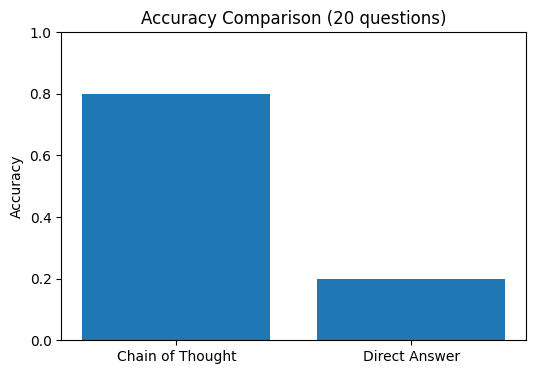

In [ ]:
evaluate_cot_vs_direct("gpt-3.5-turbo-0125", df, 8, 20)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


def evaluate_repeated_sampling(model_name: str, df: pd.DataFrame, test_size: int = 10, samples_per_question: int = 10):
    assert 'question' in df.columns and 'answer' in df.columns, "DataFrame must contain 'question' and 'answer' columns"

    correct = 0
    test_df = df.iloc[:test_size]

    for _, row in test_df.iterrows():
        question = row['question']
        real_answer = extract_answer(str(row["answer"]).replace(",", ""))

        predictions = []

        for _ in range(samples_per_question):
            try:
                response = client.chat.completions.create(
                    model=model_name,
                    messages=[{"role": "user", "content": f"For the next question, write only the final answer"}, {"role": "user", "content": f"Q: {question}\nA:"}],
                    temperature=0.5,
                )
                output = response.choices[0].message.content


                predicted = re.findall(r"-?\d+(?:[.,]\d+)?", output)
                if predicted:
                    # Take the last match and remove commas/periods unless it's a decimal point
                    pred = predicted[-1].replace(",", "").strip(".")
                    if pred:
                        predictions.append(pred)

            except Exception as e:
                print(f"[Sample Error] {e}")

        # Check if there is any success prediction
        if predictions:
            final_prediction = Counter(predictions).most_common(1)[0][0]
            if final_prediction == real_answer:
                correct += 1

    success_rate = correct / test_size

    # Plot result
    plt.figure(figsize=(6, 4))
    plt.bar(["Repeated Sampling"], [success_rate])
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title(f"Repeated Sampling Accuracy ({correct}/{test_size})")
    plt.show()


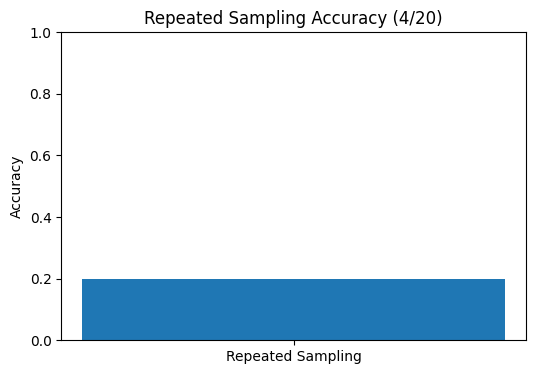

In [ ]:
evaluate_repeated_sampling("gpt-3.5-turbo-0125", df, test_size=20, samples_per_question=1)

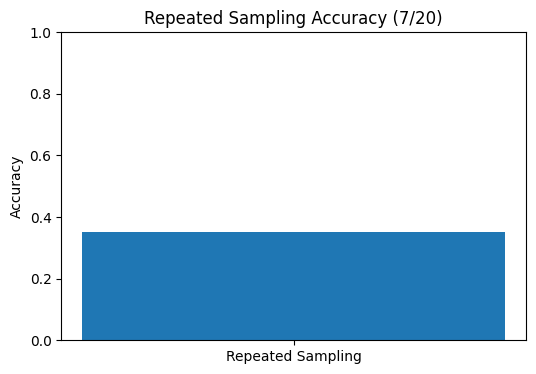

In [ ]:
evaluate_repeated_sampling("gpt-3.5-turbo-0125", df, test_size=20, samples_per_question=5)

## COT Vs Repeated sampling

In [ ]:
# Imports
from tqdm import tqdm
import pandas as pd
import re
import matplotlib.pyplot as plt
from openai import OpenAI
import pandas as pd

In [ ]:
OPENAI_API_KEY = ""

def get_data():
    splits = {'train': 'main/train-00000-of-00001.parquet', 'test': 'main/test-00000-of-00001.parquet'}
    return pd.read_parquet("hf://datasets/openai/gsm8k/" + splits["train"])

def get_openai_client():
    return OpenAI(
        # This is the default and can be omitted
        api_key=OPENAI_API_KEY
    )

def extract_answer(answer_raw: str):
    match = re.search(r"####\s*(-?\d[\d,\.]*)", answer_raw)
    return match.group(1).replace(",", "") if match else None

In [ ]:
df = get_data()
model_name = "gpt-3.5-turbo-0125"

In [ ]:
# Data set example
row = df.sample(1).iloc[0]
print("📌 Example from Dataset:\n")
print(f"Question: {row['question']} \n")
print(f"Answer: {row['answer']} \n")
print(f"Extracted Answer: {extract_answer(row['answer'])}")

📌 Example from Dataset:

Question: Mrs. Petersons bought 10 tumblers for $45 each. She paid with five $100 bills. How much change will Mrs. Petersons receive? 

Answer: The 10 tumblers amount to $45 x 10 = $<<45*10=450>>450.
Mrs. Petersons paid $100 x 5 = $<<100*5=500>>500.
So, her change will be $500 - $450 = $<<500-450=50>>50.
#### 50 

Extracted Answer: 50


In [ ]:
def measure_cot_over_k(model_name: str, df: pd.DataFrame, max_k: int = 10, test_size: int = 10):
    results = []
    client = get_openai_client()

    for k in tqdm(range(1, max_k + 1), desc="COT Progress"):
        cot_correct = 0
        few_shot_df = df.sample(n=k, random_state=42)
        test_df = df.drop(few_shot_df.index).sample(n=test_size, random_state=42).reset_index(drop=True)

        few_shot_prompt = "\n\n".join(
            f"Q: {row['question']}\nA: Let's think step by step.\n... Therefore, the answer is {row['answer']}."
            for _, row in few_shot_df.iterrows()
        )

        for _, row in test_df.iterrows():
            question = row['question']
            real_answer = extract_answer(str(row["answer"]).replace(",", ""))

            # --- CoT ---
            cot_prompt = f"{few_shot_prompt}\n\nQ: {question}\nA: Let's think step by step."
            try:
                cot_response = client.chat.completions.create(
                    model=model_name,
                    messages=[{"role": "user", "content": cot_prompt}],
                )
                output = cot_response.choices[0].message.content


                predicted = re.findall(r"-?\d+(?:[.,]\d+)?", output)
                if predicted:
                    # Take the last match and remove commas/periods unless it's a decimal point
                    cot_predicted = predicted[-1].replace(",", "").strip(".")
                    if cot_predicted == real_answer:
                        cot_correct += 1

            except Exception as e:
                print(f"[CoT Error @ k={k}] {e}")

        results.append({
            "k": k,
            "cot": cot_correct / test_size,
        })

    return results

In [ ]:
def measure_repeated_sampling_over_k(model_name: str, df: pd.DataFrame, max_k: int = 10, test_size: int = 10):
    results = []
    client = get_openai_client()
    test_df = df.sample(n=test_size, random_state=123).reset_index(drop=True)

    for k in tqdm(range(2, max_k + 1), desc="Repeated Sampling Progress"):
        correct = 0

        for _, row in test_df.iterrows():
            question = row['question']
            real_answer = extract_answer(str(row["answer"]).replace(",", ""))

            for _ in range(k):
                try:
                    response = client.chat.completions.create(
                        model=model_name,
                        messages=[
                        {"role": "user", "content": f"{question}"},
                        ],
                        temperature=0.5,
                    )
                    output = response.choices[0].message.content


                    predicted = re.findall(r"-?\d+(?:[.,]\d+)?", output)
                    if predicted:
                        # Take the last match and remove commas/periods unless it's a decimal point
                        pred = predicted[-1].replace(",", "").strip(".")
                        if pred == real_answer:
                            correct += 1
                            break

                except Exception as e:
                    print(f"[Sample Error] {e}, k: {k}, question: {question}")


        results.append({
            "k": k,
            "repeated_sampling": correct / test_size
        })

    return results

In [ ]:
cot_direct = measure_cot_over_k(model_name, df, max_k=20, test_size=100)
pd.DataFrame(cot_direct).to_csv("cot_results.csv", index=False)
repeated = measure_repeated_sampling_over_k(model_name, df, max_k=20, test_size=100)
pd.DataFrame(repeated).to_csv("repeated_sampling.csv", index=False)

In [ ]:
def plot_comparison(cot_direct_df, repeated_sampling_df):
    ks = cot_direct_df["k"].astype(int)
    cot_scores = cot_direct_df["cot"]
    repeated_scores = repeated_sampling_df["repeated_sampling"]

    plt.figure(figsize=(8, 5))
    plt.plot(ks, cot_scores, label="Chain of Thought", marker='o')
    plt.plot(ks, repeated_scores, label="Repeated Sampling", marker='o')
    plt.ylim(0, 1)
    plt.xticks(ks)
    plt.xlabel("Number of Samples (k)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs. Number of Samples")
    plt.legend()
    plt.grid(True)
    plt.show()

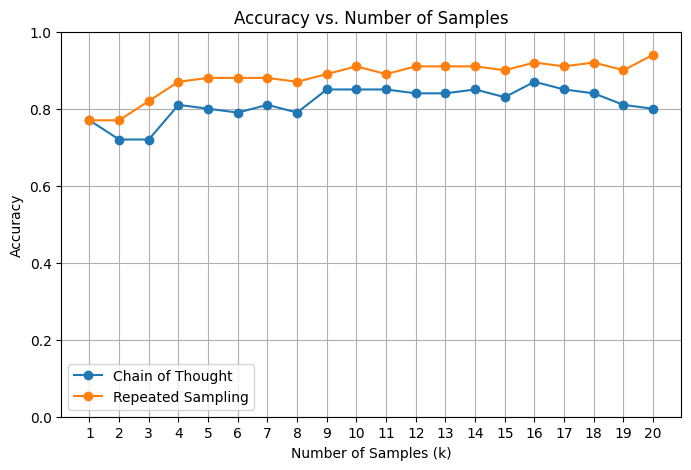

In [ ]:
cot_results = pd.read_csv("cot_results.csv")
repeated_sampling = pd.read_csv('repeated_sampling.csv')
plot_comparison(cot_results, repeated_sampling)

# 5.      Challenges, evolution, and future *directions* // Barak

### Challenges, and Future Directions (5m)

#### Challenges
Despite the impressive abilities of LLMs, several core challenges remain in reasoning tasks:
- **COT:** LLMs often mimic surface-level patterns from training data without understanding deeper logic.
- **COT:** Errors tend to compound across long reasoning chains.
- **Repeated Sampling**: Sampling thousands of outputs is computationally intensive and not feasible for many production settings.
- **Repeated Sampling**: Lack of Verfiers, unfortunately we do not have enough verifiers for all of available tasks that repeated sampling might have.
- **Scaling Laws Perspective**: (Easy Intuition) Recent work (Schaeffer et al., 2025) shows that while repeated sampling improves success rates exponentially for each individual problem, the overall improvement across a full benchmark follows a power law. This happens because not all problems are equally difficult: many problems are solved quickly, but a small fraction are extremely hard and require many samples. These rare, very difficult problems slow down the average improvement as more samples are added, creating the observed power law scaling. This insight helps researchers better predict how model performance improves when increasing the number of inference attempts. (Source - Schaeffer, R., Kazdan, J., Hughes, J., Juravsky, J., Price, S., Lynch, A., Jones, E., Kirk, R., Mirhoseini, A. and Koyejo, S., 2025. How Do Large Language Monkeys Get Their Power (Laws)?. arXiv preprint arXiv:2502.17578.
https://arxiv.org/pdf/2502.17578)

#### Future Directions
1. **Cost-Effective Inference** -
   Reducing the number of samples needed for high accuracy remains an open problem.

2. **Agentic Reasoning (CoT) Pipelines** -
Repeated sampling and chain-of-thought (CoT) prompting directly impact the evolution of agentic reasoning. CoT provides models with structured intermediate steps that help them break down complex tasks into manageable parts, a skill critical for agents that must plan and execute actions. However, as agents operate autonomously, they often face ambiguous or open-ended scenarios where deterministic answers are not enough. Here, repeated sampling adds value by generating multiple reasoning paths, allowing the agent to explore diverse solutions and select the most robust one, often with verifier models or self-reflection loops (e.g., Reflexion, ReAct). Together, these techniques form the backbone for more reliable, adaptive, and goal-driven reasoning agents that can better handle uncertainty, self-correct, and make informed decisions in real-world environments.


3. **Multimodal Reasoning** - Models reason across text, image, audio, and video together.
Some Use Cases might be Diagnosing medical scans + patient text, reviewing legal diagrams, technical drawings.


